In [12]:
import matplotlib.pyplot as plt
from ase.io import read
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from matplotlib.lines import Line2D
from ase.build import bulk



<Axes: xlabel='$2\\theta$ ($^\\circ$)', ylabel='Intensities (scaled)'>

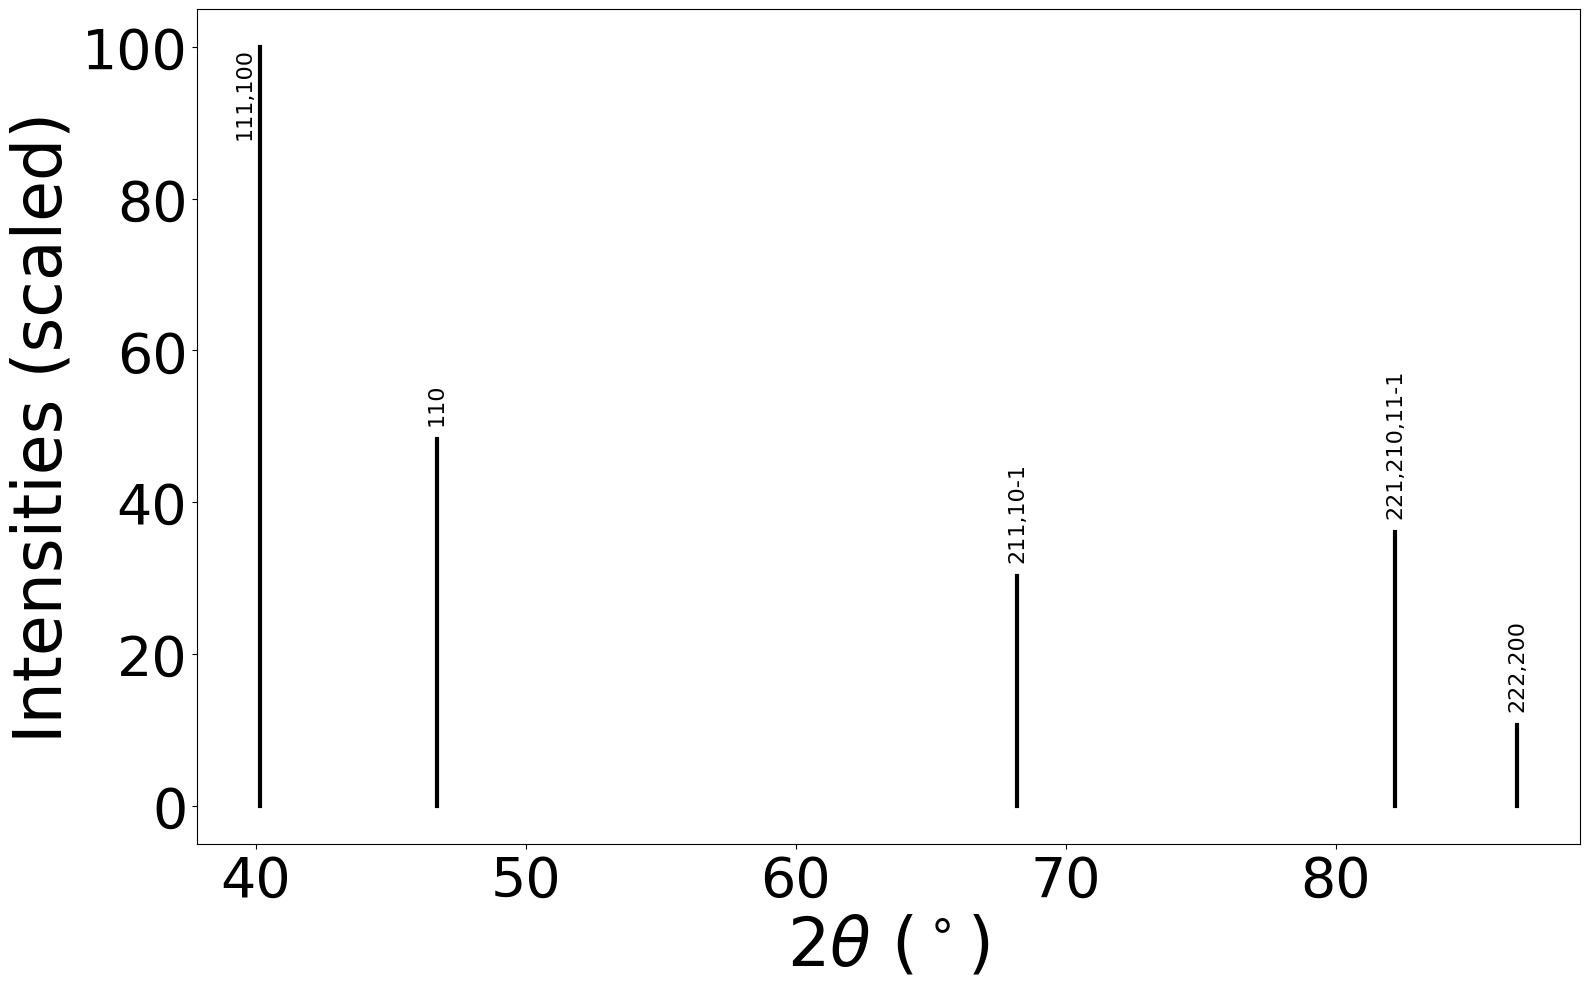

In [ ]:
# Prepare or read your structure:
atoms = bulk('Pd', cubic=False)

# Set the name based on chemical formula
name = f"{atoms.get_chemical_formula()}_xrd.png"

# Translate the ASE Atoms object to Pymatgen Structure object
structure = AseAtomsAdaptor.get_structure(atoms)

# Choose the light source for the XRD simulation
calc = XRDCalculator(wavelength="CuKa")

# The plot can be generated with one call using
calc.get_plot(structure)

The numerical data can be extracted and inspected using the following:

In [21]:
# Simulate the XRD 2 theta signals
pattern = calc.get_pattern(structure, two_theta_range=(10, 80))
print(pattern)

# Print exact peak data
for i, (two_theta, intensity, hkls, d) in enumerate(
    zip(pattern.x,  pattern.y, pattern.hkls, pattern.d_hkls), start=1
):
    print(f"Peak {i}")
    print(f"  2theta (raw) = {two_theta:.8f} deg")
    print(f"  intensity = {intensity:.8f}")
    print(f"  d-spacing = {d:.8f} Å")
    print(f"  hkls = {hkls}")
    print()

DiffractionPattern
$2\Theta$: [40.15095594 46.70162878 68.18596104]
Intensity: [100.          48.30501825  30.34564251]
Peak 1
  2theta (raw) = 40.15095594 deg
  intensity = 100.00000000
  d-spacing = 2.24589255 Å
  hkls = [{'hkl': (1, 1, 1), 'multiplicity': 2}, {'hkl': (1, 0, 0), 'multiplicity': 6}]

Peak 2
  2theta (raw) = 46.70162878 deg
  intensity = 48.30501825
  d-spacing = 1.94500000 Å
  hkls = [{'hkl': (1, 1, 0), 'multiplicity': 6}]

Peak 3
  2theta (raw) = 68.18596104 deg
  intensity = 30.34564251
  d-spacing = 1.37532269 Å
  hkls = [{'hkl': (2, 1, 1), 'multiplicity': 6}, {'hkl': (1, 0, -1), 'multiplicity': 6}]



The plot can be also improved substantially by using custom formatting.

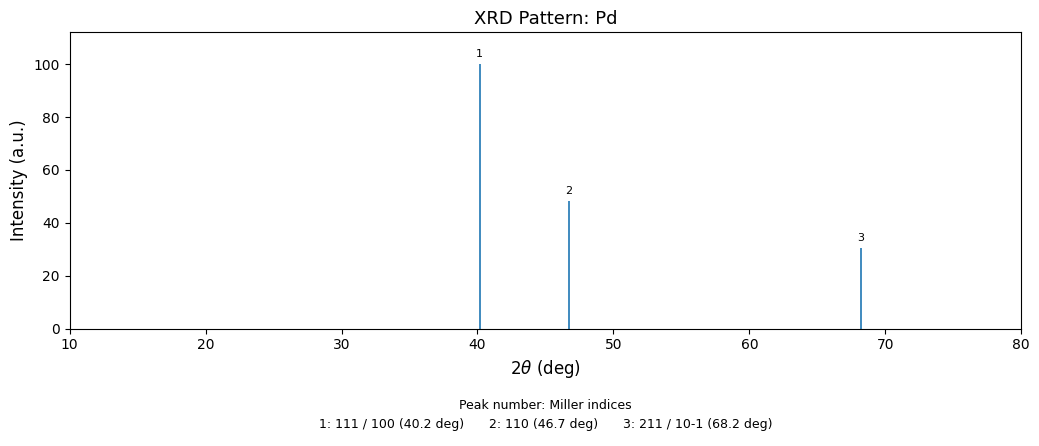

In [22]:
# Now let's generate a plot based on the recovered data
fig, ax = plt.subplots()
ax.vlines(pattern.x, 0, pattern.y, color="#1f77b4", linewidth=1.2)
ax.set_xlim(10, 80)
ax.set_ylim(0, max(pattern.y) if len(pattern.y) else 1.0)

# This helper function allows easier labelling of Miller Indices
def format_hkl(hkl):
    return "".join(str(int(i)) for i in hkl)

# This helper function generates data labels
def format_peak_hkls(hkls):
    labels = []
    for entry in hkls:
        hkl = entry["hkl"] if isinstance(entry, dict) and "hkl" in entry else entry
        labels.append(format_hkl(hkl) if isinstance(hkl, (tuple, list)) else str(hkl))

    # Preserve order but remove duplicates
    unique_labels = list(dict.fromkeys(labels))
    return " / ".join(unique_labels)


# Number peaks from left to right and place number labels above each peak
peak_entries = sorted(zip(pattern.x, pattern.y, pattern.hkls), key=lambda p: p[0])
label_offset = 0.02 * max(pattern.y) if len(pattern.y) else 1.0
peak_legend_labels = []

for peak_number, (two_theta, intensity, hkls) in enumerate(peak_entries, start=1):
    ax.text(
        two_theta,
        intensity + label_offset,
        str(peak_number),
        ha="center",
        va="bottom",
        fontsize=8,
    )
    peak_legend_labels.append(f"{peak_number}: {format_peak_hkls(hkls)} ({two_theta:.1f} deg)")

# Give extra headroom for number labels
ax.set_ylim(0, max(pattern.y) + 6 * label_offset if len(pattern.y) else ax.get_ylim()[1])

# Resize figure
fig.set_size_inches(10.5, 6.2)

# Reduce label/title sizes
ax.set_xlabel(r"2$\theta$ (deg)", fontsize=12)
ax.set_ylabel("Intensity (a.u.)", fontsize=12)
ax.set_title(f"XRD Pattern: {atoms.get_chemical_formula()}", fontsize=13)

# Reduce tick label sizes
ax.tick_params(axis="both", labelsize=10)

# Replace default legend with peak-number legend
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# Generate the legend
legend_handles = [Line2D([], [], linestyle="none", label=label) for label in peak_legend_labels]
ax.legend(
    handles=legend_handles,
    title="Peak number: Miller indices",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    frameon=False,
    fontsize=9,
    title_fontsize=9,
    handlelength=0,
    handletextpad=0,
    borderaxespad=0,
    ncol=3,
)

# Tight layout helps prevent clipping
fig.tight_layout(rect=[0, 0.2, 1, 1])

# Save without cutting text
fig.savefig(name, dpi=300, bbox_inches="tight")

plt.show()